In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from collections import defaultdict

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetV2S
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32

tabular_dir = "training dataset/tabular"
image_dir = "training dataset/image"

train_df = pd.read_csv(os.path.join(tabular_dir, "train_split.csv"))
val_df   = pd.read_csv(os.path.join(tabular_dir, "val_split.csv"))
test_df  = pd.read_csv(os.path.join(tabular_dir, "test_split.csv"))

view_cols = [c for c in train_df.columns if "View" in c and "Path" in c]

In [3]:
def build_subject_image_dict(df):
    subject_dict = {}

    for idx, row in df.iterrows():
        if row.get('Has_Images', 0) == 0:
            continue

        image_paths = []

        for col in view_cols:
            p = row[col]

            if p != "MISSING_IMAGE":
                p = p.replace('\\', os.sep).replace('/', os.sep)
                full_path = os.path.join(image_dir, p)

                image_paths.append(full_path)

        if len(image_paths) > 0:
            subject_dict[idx] = image_paths

    return subject_dict

In [4]:
train_subjects = build_subject_image_dict(train_df)
val_subjects   = build_subject_image_dict(val_df)
test_subjects  = build_subject_image_dict(test_df)

print("Train:", len(train_subjects))
print("Val:", len(val_subjects))
print("Test:", len(test_subjects))

Train: 403
Val: 62
Test: 114


In [6]:
def data_generator_from_dict(subject_dict, df):
    for subject_id, paths in subject_dict.items():
        label = df.loc[subject_id, 'Diagnosis']

        for path in paths:
            img = cv2.imread(path)

            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0

                yield img.astype(np.float32), np.int32(label)

In [7]:
def get_ds_from_dict(subject_dict, df, shuffle=False):
    ds = tf.data.Dataset.from_generator(
        lambda: data_generator_from_dict(subject_dict, df),
        output_signature=(
            tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
            tf.TensorSpec((), tf.int32)
        )
    )

    if shuffle:
        ds = ds.shuffle(500)

    ds = ds.repeat()  # 🔥 FIX

    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [8]:
def count_images(subject_dict):
    return sum(len(v) for v in subject_dict.values())

train_steps = count_images(train_subjects) // BATCH_SIZE
val_steps   = count_images(val_subjects) // BATCH_SIZE

print("Train steps:", train_steps)
print("Val steps:", val_steps)

Train steps: 37
Val steps: 5


In [9]:
labels = train_df[train_df['Has_Images'] == 1]['Diagnosis']

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.2045454545454546), 1: np.float64(0.8548387096774194)}


In [10]:
def finalize_model(inputs, x, name):
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model

In [11]:
def build_model(name):
    if name == "MobileNetV2":
        base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    elif name == "ResNet50":
        base = ResNet50(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    elif name == "EfficientNetV2S":
        base = EfficientNetV2S(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

    base.trainable = False

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)

    return finalize_model(inputs, x, name)

In [12]:
def evaluate_patient_level(model, subject_dict, df):
    y_true, y_pred = [], []

    for subject_id, paths in subject_dict.items():
        label = df.loc[subject_id, 'Diagnosis']

        preds = []

        for path in paths:
            img = cv2.imread(path)

            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
                img = np.expand_dims(img, axis=0)

                pred = model.predict(img, verbose=0)[0][0]
                preds.append(pred)

        if len(preds) == 0:
            continue

        avg_pred = np.mean(preds)
        final_pred = 1 if avg_pred > 0.5 else 0

        y_true.append(label)
        y_pred.append(final_pred)

    return y_true, y_pred

In [13]:
def run_benchmark():
    models = ["MobileNetV2", "ResNet50", "EfficientNetV2S"]
    results = {}

    train_ds = get_ds_from_dict(train_subjects, train_df, shuffle=True)
    val_ds   = get_ds_from_dict(val_subjects, val_df)

    for m_name in models:
        print(f"\n🚀 Training {m_name}")
        model = build_model(m_name)

        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=10,
            steps_per_epoch=train_steps,
            validation_steps=val_steps,
            class_weight=class_weights,
            callbacks=[
                EarlyStopping(monitor='val_auc', patience=3, mode='max', restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', patience=2)
            ]
        )

        # Evaluation
        y_true, y_pred = evaluate_patient_level(model, test_subjects, test_df)

        cm = confusion_matrix(y_true, y_pred)

        print(f"\n📊 Confusion Matrix - {m_name}")
        print(cm)

        plt.figure()
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'])
        plt.title(f'Confusion Matrix - {m_name}')
        plt.show()

        print("\n📋 Classification Report")
        print(classification_report(y_true, y_pred, zero_division=0))

        results[m_name] = {
            "Accuracy": round(np.mean(np.array(y_true) == np.array(y_pred)), 4),
            "TP": int(cm[1][1]),
            "TN": int(cm[0][0]),
            "FP": int(cm[0][1]),
            "FN": int(cm[1][0])
        }

    return pd.DataFrame(results).T


🚀 Training MobileNetV2
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 46s 632ms/step - accuracy: 0.7137 - auc: 0.5453 - loss: 1.0844 - val_accuracy: 0.8000 - val_auc: 0.6138 - val_loss: 0.9605 - learning_rate: 1.0000e-04
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 595ms/step - accuracy: 0.7272 - auc: 0.6117 - loss: 1.0162 - val_accuracy: 0.7563 - val_auc: 0.6593 - val_loss: 0.9716 - learning_rate: 1.0000e-04
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 552ms/step - accuracy: 0.7584 - auc: 0.7058 - loss: 0.9437 - val_accuracy: 0.7000 - val_auc: 0.6642 - val_loss: 0.9795 - learning_rate: 1.0000e-04
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 500ms/step - accuracy: 0.7660 - auc: 0.7112 - loss: 0.9390 - val_accuracy: 0.7063 - val_auc: 0.6536 - val_loss: 0.9791 - learning_rate: 1.0000e-05
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 504ms/step - accuracy: 0.7686 - auc: 0.7023 - loss: 0.9459 - val_accuracy: 0.6938 - val_auc: 0.6556 - val_loss: 0.9719 - learning_rate: 1.0000e-05
Epoch 6/10
37/37 ━━━━━━━━━━━━━━

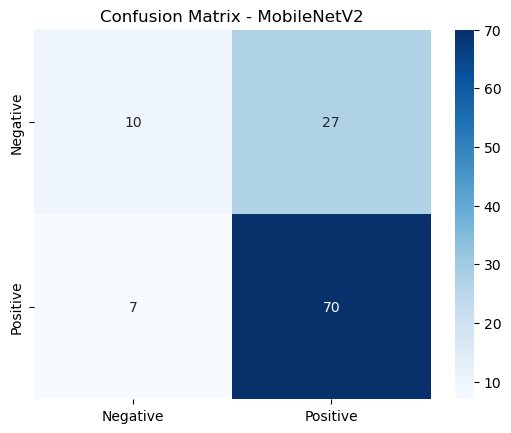


📋 Classification Report
              precision    recall  f1-score   support

           0       0.59      0.27      0.37        37
           1       0.72      0.91      0.80        77

    accuracy                           0.70       114
   macro avg       0.65      0.59      0.59       114
weighted avg       0.68      0.70      0.66       114


🚀 Training ResNet50
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.6647 - auc: 0.5123 - loss: 1.0382 - val_accuracy: 0.8500 - val_auc: 0.5178 - val_loss: 0.9121 - learning_rate: 1.0000e-04
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.7644 - auc: 0.5570 - loss: 0.9326 - val_accuracy: 0.8500 - val_auc: 0.5426 - val_loss: 0.8270 - learning_rate: 1.0000e-04
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.7677 - auc: 0.6025 - loss: 0.8750 - val_accuracy: 0.8500 - val_auc: 0.5484 - val_loss: 0.7888 - learning_rate: 1.0000e-04
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.7804 

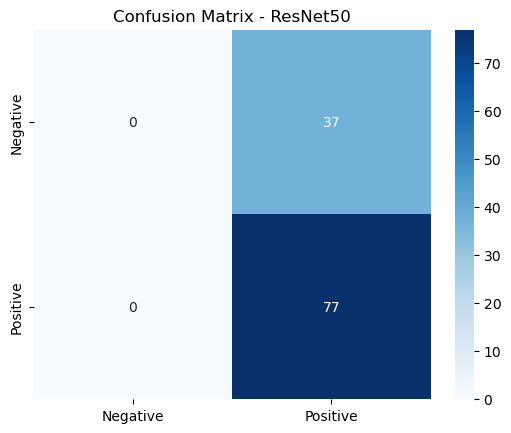


📋 Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.68      1.00      0.81        77

    accuracy                           0.68       114
   macro avg       0.34      0.50      0.40       114
weighted avg       0.46      0.68      0.54       114


🚀 Training EfficientNetV2S
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7213 - auc: 0.5076 - loss: 1.0622 - val_accuracy: 0.8562 - val_auc: 0.4295 - val_loss: 1.0579 - learning_rate: 1.0000e-04
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7120 - auc: 0.4911 - loss: 1.0597 - val_accuracy: 0.8250 - val_auc: 0.4392 - val_loss: 1.0801 - learning_rate: 1.0000e-04
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.7264 - auc: 0.5491 - loss: 1.0229 - val_accuracy: 0.8313 - val_auc: 0.4740 - val_loss: 1.0645 - learning_rate: 1.0000e-04
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 

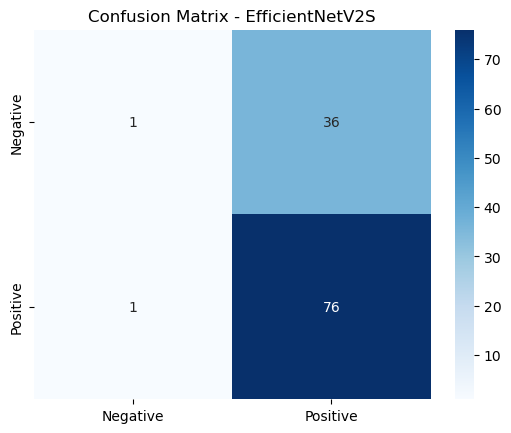


📋 Classification Report
              precision    recall  f1-score   support

           0       0.50      0.03      0.05        37
           1       0.68      0.99      0.80        77

    accuracy                           0.68       114
   macro avg       0.59      0.51      0.43       114
weighted avg       0.62      0.68      0.56       114


📊 Final Results:
                 Accuracy    TP    TN    FP   FN
MobileNetV2        0.7018  70.0  10.0  27.0  7.0
ResNet50           0.6754  77.0   0.0  37.0  0.0
EfficientNetV2S    0.6754  76.0   1.0  36.0  1.0


In [14]:
performance = run_benchmark()
print("\n📊 Final Results:")
print(performance)